# 03 - A Tiny DDPM on MNIST

In the 2D-toy notebooks we ran DDPM on points in the plane: each sample was a
length-2 vector, and the network was a small MLP that mapped
`(point, time) -> predicted noise`. That was enough to *see* the forward (add
noise) and reverse (denoise) processes, but the data lived in 2 dimensions.

Here we take the step from toys to **images**. The data is MNIST digits, which
are 2D grids of pixels. Three things change:

1. **Tensor shape.** A sample is now `(channels, height, width)` = `(1, 16, 16)`
   instead of a length-2 vector. Batches are `(B, 1, 16, 16)`.
2. **Network.** An MLP that flattens pixels ignores spatial structure. We use a
   small **convolutional U-Net** so the model can share weights across the image
   and reason about local neighborhoods.
3. **Conditioning.** Same idea as before: a sinusoidal **time embedding** tells
   the network *which* diffusion step it is denoising. We inject it into the conv
   blocks instead of concatenating it to a 2D point.

The math is identical to the 2D case (linear beta schedule, predict the noise
`eps`, sample by reversing the chain). Only the data shape and the network
architecture change.

**Compute budget warning:** everything below is sized to run on CPU in a couple
of minutes. That means a *tiny* model, a *small* data subset, downscaled 16x16
images, and very few training steps. The generated digits will be **rough and
blobby** -- recognizable as digit-ish shapes at best. That is expected; quality
needs orders of magnitude more compute. The goal is the mechanics, not pretty
pictures.

## Setup and reproducibility

We import torch, torchvision, numpy, and matplotlib, fix the seed, and resolve
the repo's `data/` directory robustly by walking up from the current working
directory until we find `pyproject.toml`. MNIST is already downloaded there, so
`download=True` is a no-op (it only verifies the files are present).

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device('cpu')

# Resolve the repo data dir regardless of where the notebook runs from.
_r = Path.cwd()
while not (_r / 'pyproject.toml').exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / 'data')
print('data root:', DATA_ROOT)

data root: C:\Users\abero\dev\applied_learning\data


## Load a small MNIST subset, downscaled to 16x16

Two cost-cutting moves keep this CPU-friendly:

- **Downscale to 16x16** with `transforms.Resize(16)`. A 28x28 image has ~3x the
  pixels; 16x16 keeps the digit legible while shrinking every conv op.
- **Subset to ~6000 images** (out of 60000). The model only needs to see enough
  variety to learn blob-shaped digits, not the full distribution.

We normalize pixels to **[-1, 1]** (`x * 2 - 1`). This matches the assumption
that the data is roughly zero-mean, which is what the Gaussian forward process
expects -- the same normalization choice we would make for the 2D toy data.

In [2]:
IMG_SIZE = 16
SUBSET_N = 6000
BATCH = 128

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),                 # -> [0, 1], shape (1, 16, 16)
    transforms.Lambda(lambda t: t * 2.0 - 1.0),  # -> [-1, 1]
])

full = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
# Deterministic subset of the first SUBSET_N indices (seed already fixed).
idx = torch.randperm(len(full))[:SUBSET_N].tolist()
train = Subset(full, idx)
loader = DataLoader(train, batch_size=BATCH, shuffle=True, drop_last=True)

xb, _ = next(iter(loader))
print('batch shape:', tuple(xb.shape), '| min/max:', float(xb.min()), float(xb.max()))

batch shape: (128, 1, 16, 16) | min/max: -1.0 1.0


## The forward (noising) process

Exactly as in the 2D case. We pick a **linear beta schedule** with `T` steps and
precompute the cumulative products `alpha_bar`. The closed-form forward step lets
us jump straight to any noise level `t` in one shot:

```
x_t = sqrt(alpha_bar[t]) * x_0 + sqrt(1 - alpha_bar[t]) * eps,   eps ~ N(0, I)
```

We keep `T` small (150) so the reverse loop at sampling time is cheap.

In [3]:
T = 150
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

sqrt_ab = torch.sqrt(alpha_bar)
sqrt_one_minus_ab = torch.sqrt(1.0 - alpha_bar)

def q_sample(x0, t, eps):
    # Add noise to x0 to reach level t (closed form). t is a (B,) long tensor.
    a = sqrt_ab[t].view(-1, 1, 1, 1)
    b = sqrt_one_minus_ab[t].view(-1, 1, 1, 1)
    return a * x0 + b * eps

print('T =', T, '| alpha_bar[0]=%.4f' % alpha_bar[0], '| alpha_bar[-1]=%.4f' % alpha_bar[-1])

T = 150 | alpha_bar[0]=0.9999 | alpha_bar[-1]=0.2192


## Sinusoidal time embedding

Same trick as the 2D notebook: map the integer timestep `t` to a smooth vector
using sines and cosines at different frequencies. This gives the network a rich,
continuous signal for *how noisy* the input is. We pass it through a tiny MLP and
then add it into each conv block.

In [4]:
def sinusoidal_embedding(t, dim):
    # t: (B,) long. Returns (B, dim).
    half = dim // 2
    freqs = torch.exp(-np.log(10000.0) * torch.arange(half, dtype=torch.float32) / half)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)

## A compact convolutional U-Net

This is the heart of what changed from the 2D toy. Instead of an MLP over a
length-2 vector, we use a small U-Net over a `(1, 16, 16)` image:

- **One downsample / one upsample stage** (16x16 -> 8x8 -> 16x16). One stage is
  enough at this tiny resolution and keeps it fast.
- **Base channels = 16** at full res, 32 at the bottleneck. Small on purpose.
- **Skip connection** from the encoder to the decoder (the U in U-Net) so fine
  detail survives the down/up trip.
- The **time embedding** is projected per block and **added** to the feature maps
  (broadcast across height and width).

The network still does the same job: input a noisy image plus its timestep,
output a prediction of the noise `eps` that was added.

In [5]:
class TimeBlock(nn.Module):
    # Two 3x3 convs with a time-embedding bias injected between them.
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.temb = nn.Linear(t_dim, out_ch)
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.conv1(x))
        h = h + self.temb(t_emb).unsqueeze(-1).unsqueeze(-1)  # (B,C,1,1) broadcast
        h = self.act(self.conv2(h))
        return h


class TinyUNet(nn.Module):
    def __init__(self, base=16, t_dim=64):
        super().__init__()
        self.t_dim = t_dim
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        # Encoder: 16x16 @ base, then downsample to 8x8 @ 2*base.
        self.down1 = TimeBlock(1, base, t_dim)
        self.pool = nn.AvgPool2d(2)
        self.down2 = TimeBlock(base, base * 2, t_dim)
        # Bottleneck at 8x8.
        self.mid = TimeBlock(base * 2, base * 2, t_dim)
        # Decoder: upsample to 16x16, concat skip, back to base.
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = TimeBlock(base * 2 + base, base, t_dim)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x, t):
        te = self.t_mlp(sinusoidal_embedding(t, self.t_dim))
        h1 = self.down1(x, te)            # (B, base, 16, 16)
        h2 = self.down2(self.pool(h1), te)  # (B, 2base, 8, 8)
        m = self.mid(h2, te)              # (B, 2base, 8, 8)
        u = self.up(m)                    # (B, 2base, 16, 16)
        u = torch.cat([u, h1], dim=1)     # skip connection
        u = self.up1(u, te)              # (B, base, 16, 16)
        return self.out(u)                # (B, 1, 16, 16) predicted eps

model = TinyUNet(base=16, t_dim=64).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print('model params: %d (~%.0fk)' % (n_params, n_params / 1000))

model params: 58689 (~59k)


## Training loop

The DDPM training objective is the same as the 2D case: pick a random timestep
`t` per example, noise the image to that level, and ask the network to predict
the noise. The loss is plain MSE between predicted and actual `eps`.

We train for only a handful of epochs over the 6000-image subset. We record the
average loss per epoch to plot afterward. (If the loss is still trending down,
that is the compute budget talking -- more steps would keep helping.)

In [6]:
EPOCHS = 4
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

loss_hist = []
t0 = time.time()
model.train()
for ep in range(EPOCHS):
    running = 0.0
    n = 0
    for xb, _ in loader:
        xb = xb.to(DEVICE)
        b = xb.size(0)
        t = torch.randint(0, T, (b,), device=DEVICE)
        eps = torch.randn_like(xb)
        xt = q_sample(xb, t, eps)
        pred = model(xt, t)
        loss = F.mse_loss(pred, eps)
        opt.zero_grad()
        loss.backward()
        opt.step()
        running += loss.item() * b
        n += b
    avg = running / n
    loss_hist.append(avg)
    print('epoch %d/%d  loss=%.4f  elapsed=%.1fs' % (ep + 1, EPOCHS, avg, time.time() - t0))
print('train wall time: %.1fs' % (time.time() - t0))

epoch 1/4  loss=0.7387  elapsed=2.2s


epoch 2/4  loss=0.3559  elapsed=4.5s


epoch 3/4  loss=0.2519  elapsed=7.0s


epoch 4/4  loss=0.1936  elapsed=9.4s
train wall time: 9.4s


## Loss curve

A downward MSE trend means the network is getting better at predicting the noise.
With this tiny budget the curve usually keeps sloping down -- the model is
nowhere near converged, by design.

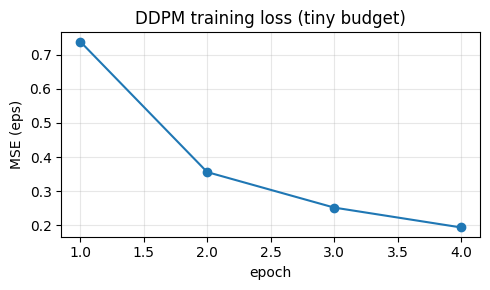

In [7]:
plt.figure(figsize=(5, 3))
plt.plot(range(1, len(loss_hist) + 1), loss_hist, marker='o')
plt.xlabel('epoch')
plt.ylabel('MSE (eps)')
plt.title('DDPM training loss (tiny budget)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sampling: run the reverse process

To generate a digit we start from pure Gaussian noise `x_T` and walk the chain
backward to `x_0`, one step at a time. At each step the network predicts the
noise, we subtract a scaled version of it, and add a little fresh noise (except
at the final step). This is the standard DDPM ancestral sampler -- identical in
structure to the 2D toy, just operating on `(1, 16, 16)` tensors now.

We generate **64 samples** to fill an 8x8 grid.

In [8]:
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_var = betas * (1.0 - torch.cat([torch.tensor([1.0]), alpha_bar[:-1]])) / (1.0 - alpha_bar)

@torch.no_grad()
def sample(n):
    model.eval()
    x = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=DEVICE, dtype=torch.long)
        eps_pred = model(x, t)
        coef = betas[i] / sqrt_one_minus_ab[i]
        mean = sqrt_recip_alphas[i] * (x - coef * eps_pred)
        if i > 0:
            x = mean + torch.sqrt(posterior_var[i]) * torch.randn_like(x)
        else:
            x = mean
    return x

ts = time.time()
samples = sample(64)
print('sampled 64 images in %.1fs | shape %s' % (time.time() - ts, tuple(samples.shape)))

sampled 64 images in 0.8s | shape (64, 1, 16, 16)


## Display the generated digit grid

We map pixels back from [-1, 1] to [0, 1] and tile the 64 samples into an 8x8
grid. Expect **rough, blurry blobs** with some digit-like strokes -- a few may
look like a 0, 1, 7, or 9; many will be ambiguous smudges. That is the honest
result of a ~30k-parameter model trained for a handful of epochs on 6000
downscaled images. The pipeline is correct; only the compute is tiny.

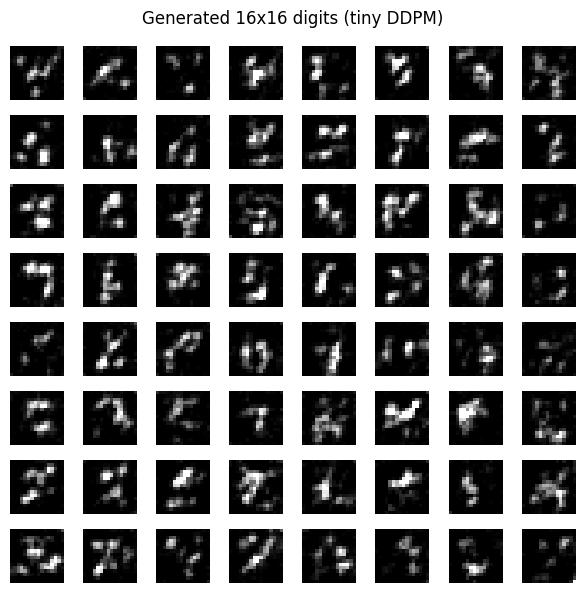

In [9]:
imgs = (samples.clamp(-1, 1) + 1.0) / 2.0  # -> [0, 1]
imgs = imgs.squeeze(1).cpu().numpy()

fig, axes = plt.subplots(8, 8, figsize=(6, 6))
for ax, img in zip(axes.ravel(), imgs):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
fig.suptitle('Generated 16x16 digits (tiny DDPM)')
plt.tight_layout()
plt.show()

## Recap: what changed from the 2D toy

| Aspect | 2D toy DDPM | This notebook |
|---|---|---|
| Sample shape | `(2,)` point | `(1, 16, 16)` image |
| Network | MLP | convolutional U-Net (down/up + skip) |
| Time conditioning | concat embedding to point | sinusoidal embed added per conv block |
| Forward process | linear betas, closed-form `q_sample` | *identical* |
| Loss | MSE on predicted `eps` | *identical* |
| Sampler | reverse the chain | *identical*, on image tensors |

The diffusion *recipe* is unchanged. Moving to images is mostly a swap of the
data tensor shape and the denoising network (MLP -> conv U-Net). The next step
up would be: full 28x28 resolution, more channels and stages, more training
steps, and an EMA of the weights -- all of which cost real GPU time and are out
of scope for a CPU teaching notebook.